<a href="https://colab.research.google.com/github/izhanys/PBA_Bima_5026231060/blob/main/Tugas/Week%203/Week_3_3_bow_regex_Bima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bag of Words + Regex Google Apps Review-Bima+**

In [2]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

import pandas as pd
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

Load & Sample Data

In [3]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df_full = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df_full):,} rows')

Saving review_bima_75000.csv to review_bima_75000.csv
Loaded: 75,000 rows


In [4]:
df_full['sentiment'] = df_full['score'].apply(
    lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral')
)

# sample 25 positive + 25 negative
pos = df_full[df_full['sentiment'] == 'positive'].sample(25, random_state=42)
neg = df_full[df_full['sentiment'] == 'negative'].sample(25, random_state=42)
df = pd.concat([pos, neg]).reset_index(drop=True)

print(f'Sampled {len(df)} reviews: {len(pos)} positive + {len(neg)} negative')
df[['content', 'score', 'sentiment']].head()

Sampled 50 reviews: 25 positive + 25 negative


,content,score,sentiment
0,manta,5,positive
1,sangat membantu sekali,5,positive
2,sangat 👍,5,positive
3,cepat,5,positive
4,kok jaringan tri makin kesini jaringan nya mak...,4,positive


BOW Step 1: Tokenize, Remove Stopwords, Lemmatize

In [5]:
lemmatizer = WordNetLemmatizer()
stop_id = set(stopwords.words('indonesian'))

corpus = []
for text in df['content'].astype(str):
    sent = re.sub('[^a-zA-Z]', ' ', text)
    sent = sent.lower().split()
    sent = [lemmatizer.lemmatize(w) for w in sent if w not in stop_id and len(w) > 2]
    corpus.append(' '.join(sent))

print(f'{len(corpus)} documents processed')
print('Sample:', corpus[:3])

50 documents processed
Sample: ['manta', 'membantu', '']


BOW Step 2: Unique Words

In [6]:
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = list(set(all_words))
print(f'Total words: {len(all_words)}')
print(f'Unique words: {len(unique_words)}')
print('Sample unique:', unique_words[:15])

Total words: 361
Unique words: 228
Sample unique: ['the', 'jaringan', 'menarik', 'muncul', 'mantap', 'menghubungi', 'jgn', 'kali', 'susah', 'wkwkw', 'aneh', 'stikernya', 'buruk', 'beli', 'poin']


BOW Step 3: Word Frequency & Vectorization

In [7]:
word_freq = Counter(all_words)
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# word-to-number mapping
word_to_num = {w: i+1 for i, (w, _) in enumerate(sorted_words)}

print('Top 15 words:')
for w, c in sorted_words[:15]:
    print(f'  {w:20s} {c:>4}')

Top 15 words:
  nya                    11
  kuota                  11
  jaringan                9
  mahal                   9
  paket                   8
  beli                    7
  sinyal                  6
  tri                     5
  hilang                  5
  aja                     5
  udh                     5
  mulu                    5
  kadang                  4
  bagus                   4
  gak                     4


In [8]:
cv = CountVectorizer()
bow_matrix = cv.fit_transform(corpus).toarray()

print(f'BoW matrix: {bow_matrix.shape[0]} docs x {bow_matrix.shape[1]} features')

bow_df = pd.DataFrame(bow_matrix, columns=cv.get_feature_names_out())
bow_df.head()

BoW matrix: 50 docs x 228 features


,abal,abis,account,aja,aje,akhirat,ampe,aneh,anggap,ape,...,udh,ulang,urus,via,virtual,wajar,wkwkw,woy,yaelah,you
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


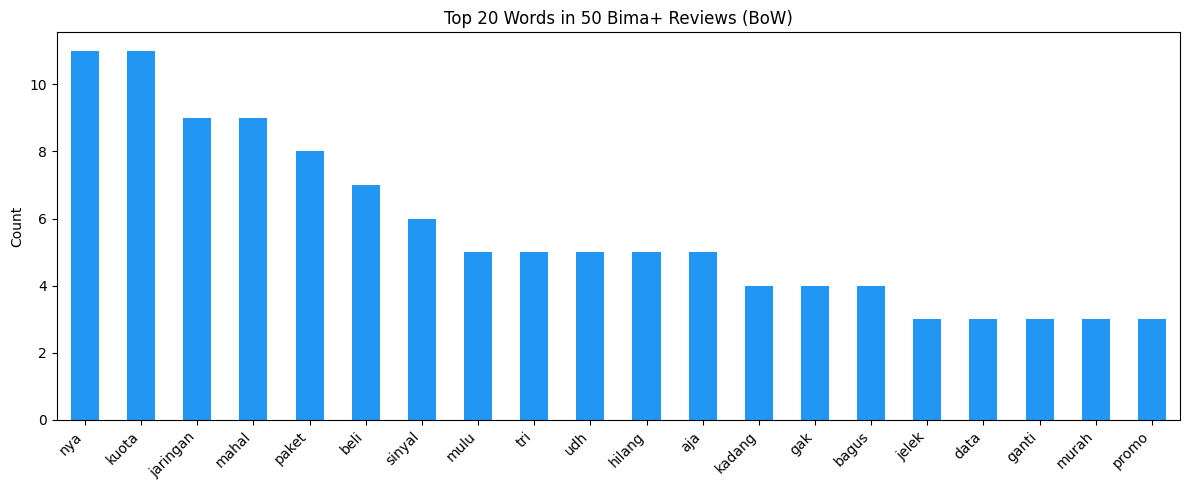

In [9]:
term_freq = bow_df.sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
term_freq.plot.bar(color='#2196F3')
plt.title('Top 20 Words in 50 Bima+ Reviews (BoW)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Regex Analysis: Positive & Negative Insights

In [10]:
raw = df_full['content'].astype(str)

# negative patterns
neg_patterns = {
    'error/crash': r'error|crash|bug|force close',
    'gagal/tidak bisa': r'gagal|tidak bisa|gabisa|gbisa|gak bisa|tdk bisa',
    'lambat/lemot': r'lambat|lemot|lama|loading',
    'kecewa': r'kecewa|rugi|bohong|tipu|nipu',
}

# positive patterns
pos_patterns = {
    'promo/cashback': r'promo|cashback|diskon|voucher|kupon',
    'bagus/mantap': r'bagus|mantap|keren|top|oke|recommended',
    'mudah/gampang': r'mudah|gampang|simpel|praktis',
    'murah/hemat': r'murah|hemat|terjangkau|worth',
}

print('=== NEGATIVE PATTERNS ===')
for label, pattern in neg_patterns.items():
    count = raw.str.contains(pattern, case=False, na=False).sum()
    pct = count / len(raw) * 100
    print(f'  {label:20s}: {count:>5,} reviews ({pct:.1f}%)')

print()
print('=== POSITIVE PATTERNS ===')
for label, pattern in pos_patterns.items():
    count = raw.str.contains(pattern, case=False, na=False).sum()
    pct = count / len(raw) * 100
    print(f'  {label:20s}: {count:>5,} reviews ({pct:.1f}%)')

=== NEGATIVE PATTERNS ===
  error/crash         :   735 reviews (1.0%)
  gagal/tidak bisa    : 3,544 reviews (4.7%)
  lambat/lemot        : 6,212 reviews (8.3%)
  kecewa              : 3,211 reviews (4.3%)

=== POSITIVE PATTERNS ===
  promo/cashback      : 2,838 reviews (3.8%)
  bagus/mantap        : 16,988 reviews (22.7%)
  mudah/gampang       : 1,732 reviews (2.3%)
  murah/hemat         : 4,744 reviews (6.3%)


In [11]:
print('Average rating per pattern:\n')
for label, pattern in {**neg_patterns, **pos_patterns}.items():
    mask = raw.str.contains(pattern, case=False, na=False)
    if mask.sum() > 0:
        avg = df_full.loc[mask, 'score'].mean()
        print(f'  {label:20s}: avg rating {avg:.2f} (n={mask.sum()})')

Average rating per pattern:

  error/crash         : avg rating 1.91 (n=735)
  gagal/tidak bisa    : avg rating 1.70 (n=3544)
  lambat/lemot        : avg rating 1.83 (n=6212)
  kecewa              : avg rating 1.46 (n=3211)
  promo/cashback      : avg rating 3.36 (n=2838)
  bagus/mantap        : avg rating 4.39 (n=16988)
  mudah/gampang       : avg rating 4.55 (n=1732)
  murah/hemat         : avg rating 3.74 (n=4744)


In [12]:
print('=== SAMPLE NEGATIVE REVIEWS ===')
for label, pattern in neg_patterns.items():
    matches = df_full[raw.str.contains(pattern, case=False, na=False)]
    if len(matches) > 0:
        sample = matches.iloc[0]
        print(f'\n[{label}] Rating: {sample["score"]}')
        print(f'  {str(sample["content"])[:200]}')

=== SAMPLE NEGATIVE REVIEWS ===

[error/crash] Rating: 1
  kartu setannn jaringan errorr anjinggg kartu bangsattt penipu setannn

[gagal/tidak bisa] Rating: 4
  beli paketan+ vidio kok vidionya tidak bisa di klaim bagaimana ini lucu

[lambat/lemot] Rating: 1
  produk sampah!udah sinyal suka ilang tiba tiba,lemot juga. katanya sinyal kuat hemat,ga sesuai!

[kecewa] Rating: 1
  kartu setannn jaringan errorr anjinggg kartu bangsattt penipu setannn
